# Industry-Level Network Analysis
Build a meta-graph where nodes are industry divisions and edge weights are the average cosine similarity between constituent stocks.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path
from itertools import combinations

# --- Configuration ---
OUTPUT_DIR = Path("output")
METADATA_DIR = Path("ticker_metadata")

DIVISIONS = {
    range(100, 1000): "Agriculture, Forestry and Fishing",
    range(1000, 1500): "Mining",
    range(1500, 1800): "Construction",
    range(1800, 2000): "Not Used",
    range(2000, 4000): "Manufacturing",
    range(4000, 5000): "Transportation & Communications",
    range(5000, 5200): "Wholesale Trade",
    range(5200, 6000): "Retail Trade",
    range(6000, 6800): "Finance, Insurance & Real Estate",
    range(7000, 9000): "Services",
    range(9100, 9730): "Public Administration",
    range(9900, 10000): "Nonclassifiable",
}

def get_division(sic_code):
    """Map a numeric SIC code to its broad industry division."""
    try:
        code = int(sic_code)
        for code_range, name in DIVISIONS.items():
            if code in code_range:
                return name
    except (ValueError, TypeError):
        pass
    return None

In [2]:
# 1. Load the similarity matrix
sim_df = pd.read_csv(OUTPUT_DIR / "ticker_similarities.csv", index_col=0)
sim_tickers = set(sim_df.index)
print(f"Similarity matrix: {sim_df.shape[0]} tickers")

# 2. Load SICCD mapping, keep only tickers present in the similarity matrix
siccd_df = pd.read_csv(METADATA_DIR / "ticker_siccd.txt", sep="\t")
siccd_df = siccd_df[siccd_df["ticker"].isin(sim_tickers)]

# 3. Map each ticker to a division; drop those without a valid mapping
siccd_df["division"] = siccd_df["siccd"].apply(get_division)
siccd_df = siccd_df.dropna(subset=["division"])

# 3b. Filter out divisions with fewer than 30 stocks
div_counts_raw = siccd_df["division"].value_counts()
valid_divisions = div_counts_raw[div_counts_raw >= 30].index
removed = div_counts_raw[div_counts_raw < 30]
if len(removed):
    print("Removed divisions (< 30 stocks):")
    for div, count in removed.items():
        print(f"  {div}: {count}")
siccd_df = siccd_df[siccd_df["division"].isin(valid_divisions)]

ticker_to_div = dict(zip(siccd_df["ticker"], siccd_df["division"]))
print(f"\nTickers with valid SICCD in similarity data: {len(ticker_to_div)}")

# 4. Filter the similarity matrix to only these tickers
valid_tickers = sorted(ticker_to_div.keys())
sim_filtered = sim_df.loc[valid_tickers, valid_tickers]
print(f"Filtered similarity matrix: {sim_filtered.shape}")

# Show stock counts per division
div_counts = pd.Series(ticker_to_div.values()).value_counts()
print("\nStocks per Division:")
for div, count in div_counts.items():
    print(f"  {div}: {count}")

Similarity matrix: 2441 tickers
Removed divisions (< 30 stocks):
  Agriculture, Forestry and Fishing: 5
  Public Administration: 1

Tickers with valid SICCD in similarity data: 2429
Filtered similarity matrix: (2429, 2429)

Stocks per Division:
  Manufacturing: 674
  Finance, Insurance & Real Estate: 545
  Nonclassifiable: 362
  Services: 309
  Transportation & Communications: 215
  Mining: 120
  Retail Trade: 106
  Wholesale Trade: 61
  Construction: 37


In [3]:
# 5. Build the industry meta-graph
# For every pair of divisions (including self-pairs), compute the average
# cosine distance (1 - cosine similarity) across all stock pairs.

division_to_tickers = defaultdict(list)
for t, d in ticker_to_div.items():
    division_to_tickers[d].append(t)

divisions = sorted(division_to_tickers.keys())
sim_values = sim_filtered.values
ticker_idx = {t: i for i, t in enumerate(sim_filtered.index)}

G_industry = nx.Graph()

for i, div_a in enumerate(divisions):
    for div_b in divisions[i:]:
        tickers_a = division_to_tickers[div_a]
        tickers_b = division_to_tickers[div_b]

        dists = []
        for t_a in tickers_a:
            for t_b in tickers_b:
                if t_a == t_b:
                    continue
                dists.append(1 - sim_values[ticker_idx[t_a], ticker_idx[t_b]])

        if dists:
            avg_dist = np.mean(dists)
            G_industry.add_edge(div_a, div_b, weight=avg_dist, pair_count=len(dists))

print(f"Industry meta-graph: {G_industry.number_of_nodes()} nodes, {G_industry.number_of_edges()} edges")
print("\nEdge sample (lowest distance = most similar):")
for u, v, d in sorted(G_industry.edges(data=True), key=lambda x: x[2]['weight'])[:5]:
    print(f"  {u[:30]:<32} <-> {v[:30]:<32}  avg_dist={d['weight']:.4f}  pairs={d['pair_count']}")

Industry meta-graph: 9 nodes, 45 edges

Edge sample (lowest distance = most similar):
  Construction                     <-> Construction                      avg_dist=0.5933  pairs=1332
  Mining                           <-> Mining                            avg_dist=0.6386  pairs=14280
  Finance, Insurance & Real Esta   <-> Finance, Insurance & Real Esta    avg_dist=0.6388  pairs=296480
  Construction                     <-> Wholesale Trade                   avg_dist=0.6703  pairs=2257
  Construction                     <-> Finance, Insurance & Real Esta    avg_dist=0.6776  pairs=20165


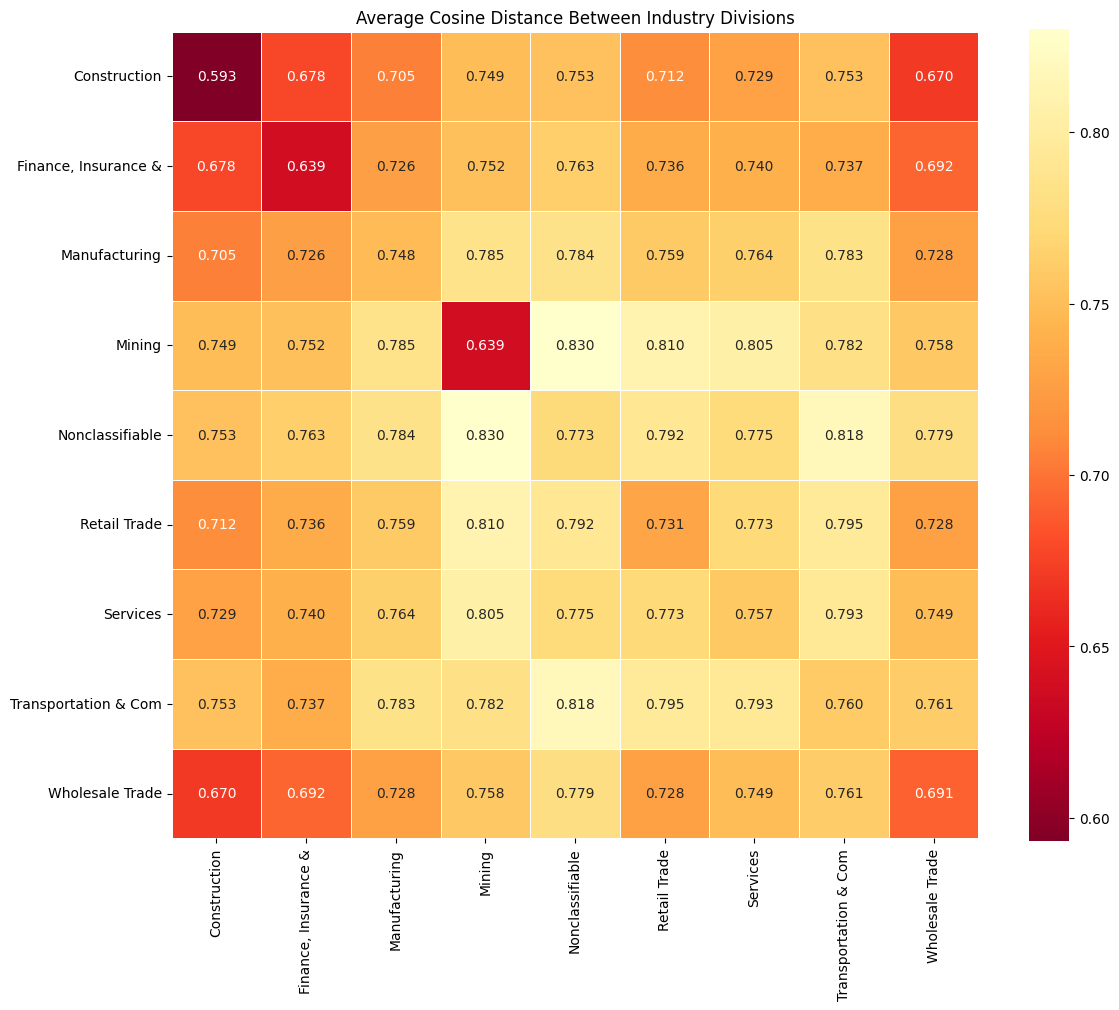

In [4]:
# 6. Heatmap of inter-division average cosine distance
heat_matrix = pd.DataFrame(np.nan, index=divisions, columns=divisions)

for u, v, d in G_industry.edges(data=True):
    heat_matrix.loc[u, v] = d["weight"]
    heat_matrix.loc[v, u] = d["weight"]

# Shorten labels for readability
short = {d: d[:20] for d in divisions}
heat_matrix = heat_matrix.rename(index=short, columns=short)

plt.figure(figsize=(12, 10))
sns.heatmap(heat_matrix.astype(float), annot=True, fmt=".3f",
            cmap="YlOrRd_r", linewidths=0.5, square=True)
plt.title("Average Cosine Distance Between Industry Divisions")
plt.tight_layout()
plt.show()

MST edges (sorted by distance):
  Construction                     <-> Wholesale Trade                   dist=0.6703
  Construction                     <-> Finance, Insurance & Real Esta    dist=0.6776
  Construction                     <-> Manufacturing                     dist=0.7052
  Construction                     <-> Retail Trade                      dist=0.7121
  Construction                     <-> Services                          dist=0.7286
  Finance, Insurance & Real Esta   <-> Transportation & Communication    dist=0.7372
  Construction                     <-> Mining                            dist=0.7487
  Construction                     <-> Nonclassifiable                   dist=0.7530

Total MST weight: 5.7327


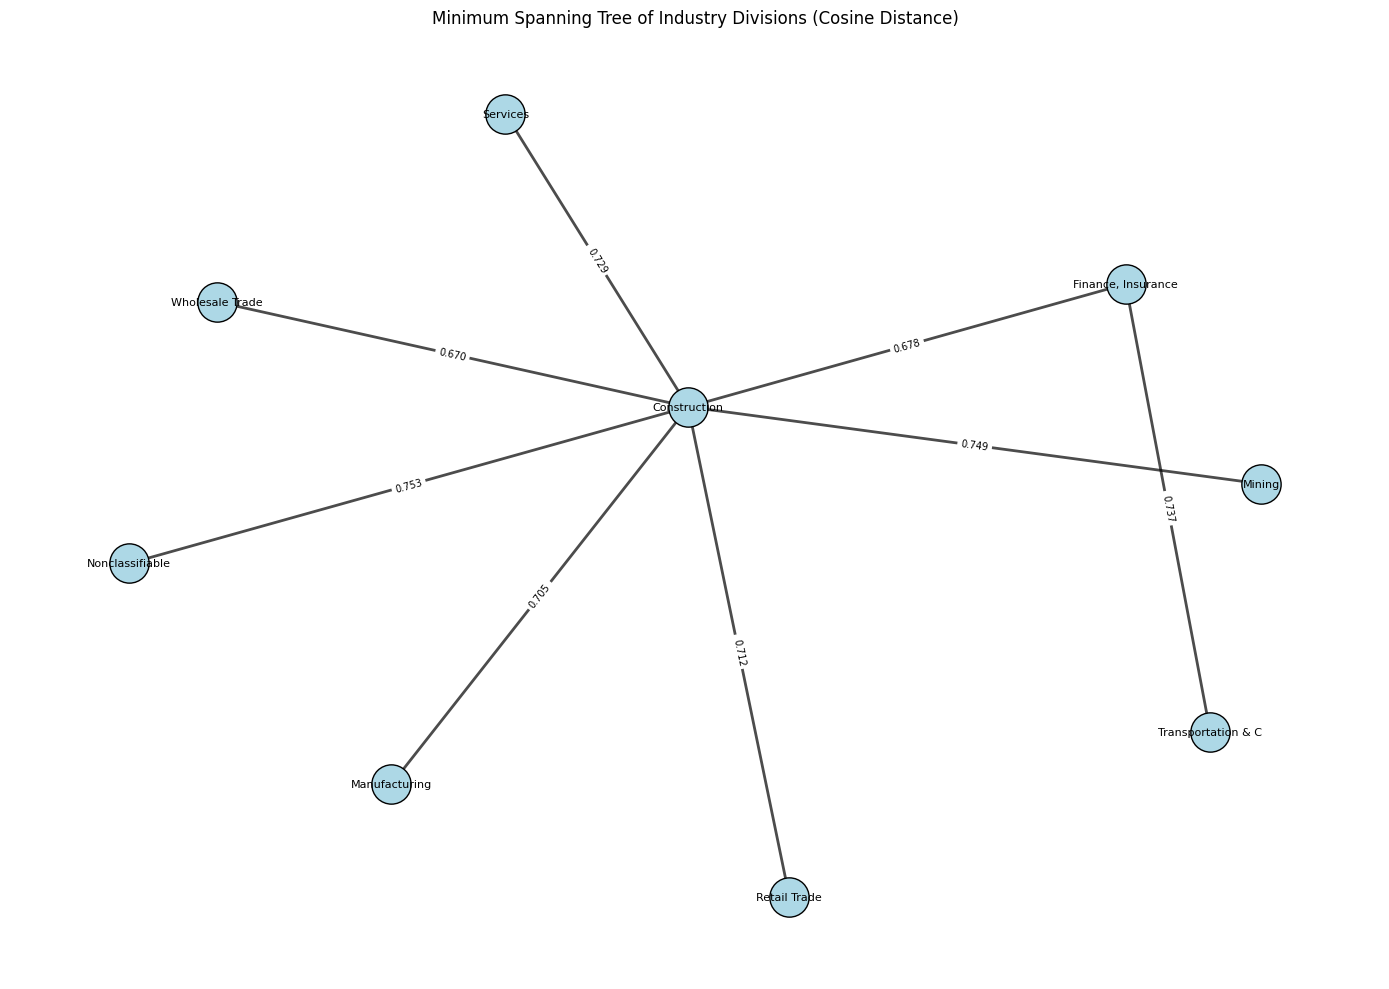

In [5]:
# 7. Minimum Spanning Tree of the industry meta-graph
# Remove self-loops before computing MST
G_no_self = G_industry.copy()
G_no_self.remove_edges_from(nx.selfloop_edges(G_no_self))

mst = nx.minimum_spanning_tree(G_no_self, weight="weight")

print("MST edges (sorted by distance):")
for u, v, d in sorted(mst.edges(data=True), key=lambda x: x[2]["weight"]):
    print(f"  {u[:30]:<32} <-> {v[:30]:<32}  dist={d['weight']:.4f}")
print(f"\nTotal MST weight: {sum(d['weight'] for _, _, d in mst.edges(data=True)):.4f}")

# Draw MST
plt.figure(figsize=(14, 10))
short_labels = {n: n[:18] for n in mst.nodes()}
pos = nx.spring_layout(mst, seed=345, k=2)

edge_weights = [d["weight"] for _, _, d in mst.edges(data=True)]

nx.draw_networkx_nodes(mst, pos, node_size=800, node_color="lightblue", edgecolors="black")
nx.draw_networkx_labels(mst, pos, labels=short_labels, font_size=8)
nx.draw_networkx_edges(mst, pos, width=2, alpha=0.7)
nx.draw_networkx_edge_labels(
    mst, pos,
    edge_labels={(u, v): f"{d['weight']:.3f}" for u, v, d in mst.edges(data=True)},
    font_size=7,
)
plt.title("Minimum Spanning Tree of Industry Divisions (Cosine Distance)")
plt.axis("off")
plt.tight_layout()
plt.show()

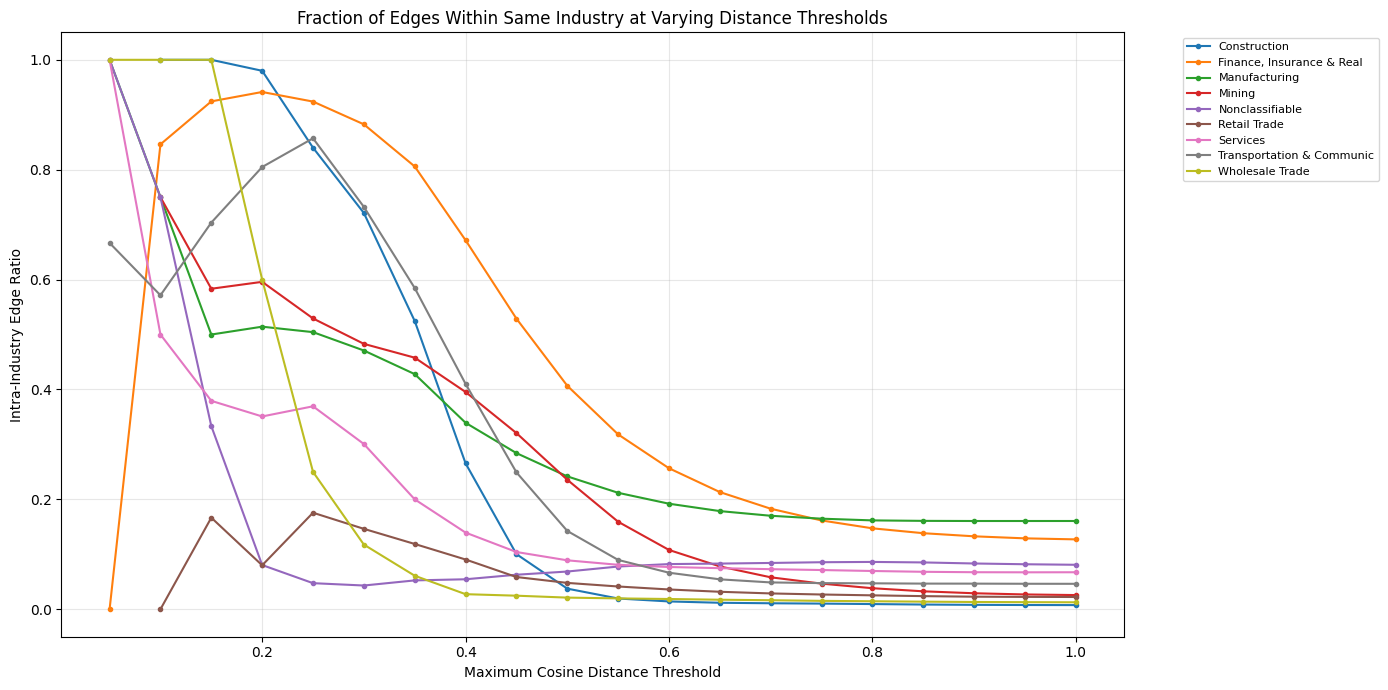

Intra-industry edge ratio at key thresholds:
threshold                           0.1    0.2    0.3    0.5    0.7    1.0
division                                                                  
Construction                      1.000  0.980  0.721  0.037  0.011  0.008
Finance, Insurance & Real Estate  0.846  0.941  0.883  0.407  0.183  0.127
Manufacturing                     0.750  0.514  0.471  0.242  0.170  0.161
Mining                            0.750  0.596  0.483  0.236  0.058  0.026
Nonclassifiable                   0.750  0.080  0.043  0.069  0.084  0.081
Retail Trade                      0.000  0.080  0.146  0.048  0.029  0.022
Services                          0.500  0.351  0.301  0.089  0.073  0.067
Transportation & Communications   0.571  0.805  0.732  0.142  0.049  0.046
Wholesale Trade                   1.000  0.600  0.118  0.021  0.016  0.013


In [6]:
# 8. Intra- vs inter-industry edge ratio at varying distance thresholds
# For each threshold, consider edges with cosine distance ≤ threshold.
# For each industry, compute: intra-industry edges / inter-industry edges.

dist_matrix = 1 - sim_filtered.values
tickers_list = list(sim_filtered.index)
n = len(tickers_list)

# Precompute division labels aligned with the matrix
div_labels = np.array([ticker_to_div[t] for t in tickers_list])

# Extract upper-triangle indices (no self-loops)
i_idx, j_idx = np.triu_indices(n, k=1)
edge_dists = dist_matrix[i_idx, j_idx]
same_div = div_labels[i_idx] == div_labels[j_idx]
div_i = div_labels[i_idx]
div_j = div_labels[j_idx]

thresholds = np.arange(0.05, 1.01, 0.05)
unique_divs = sorted(set(div_labels))

# For each threshold and division, count intra and inter edges
results = []
for thresh in thresholds:
    mask = edge_dists <= thresh
    for div in unique_divs:
        # Edges involving this division
        involves_div = (div_i[mask] == div) | (div_j[mask] == div)
        intra = np.sum((div_i[mask] == div) & (div_j[mask] == div))
        inter = np.sum(involves_div) - intra
        total = intra + inter
        ratio = intra / inter if inter > 0 else np.nan
        results.append({
            "threshold": thresh,
            "division": div,
            "intra": int(intra),
            "inter": int(inter),
            "total": int(total),
            "intra_ratio": intra / total if total > 0 else np.nan,
        })

ratio_df = pd.DataFrame(results)

# Plot intra-industry ratio vs threshold for each division
plt.figure(figsize=(14, 7))
for div in unique_divs:
    sub = ratio_df[ratio_df["division"] == div]
    sub = sub[sub["total"] > 0]
    plt.plot(sub["threshold"], sub["intra_ratio"], marker="o", markersize=3, label=div[:25])

plt.xlabel("Maximum Cosine Distance Threshold")
plt.ylabel("Intra-Industry Edge Ratio")
plt.title("Fraction of Edges Within Same Industry at Varying Distance Thresholds")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Also show a summary table at a few key thresholds
key_thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
summary = ratio_df[ratio_df["threshold"].round(2).isin(key_thresholds)].pivot_table(
    index="division", columns="threshold", values="intra_ratio"
)
print("Intra-industry edge ratio at key thresholds:")
print(summary.round(3).to_string())